# Airtel Network Intelligence: Alarm Causality, Root Cause, and Impact Analysis

This notebook analyzes network alarms to:
1. Identify causal and temporal chains of alarms.
2. Trace the root cause of these chains.
3. Forecast downstream impact (e.g. affected customers or max severity).
4. Correlate alarms with customer complaints.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import networkx as nx
import joblib
import os


os.makedirs('models', exist_ok=True)


## 1. Load Data

In [2]:

alarms = pd.read_excel('alarm.xlsx')
complaints = pd.read_excel('complain.xlsx')

alarms['alarm_timestamp'] = pd.to_datetime(alarms['alarm_timestamp'])

print("Alarms Shape:", alarms.shape)
print("Complaints Shape:", complaints.shape)


Alarms Shape: (50000, 26)
Complaints Shape: (20000, 16)


## 2. Causal and Temporal Chaining
We will sort alarms by timestamp and node to identify temporal chains.

In [3]:

alarms = alarms.sort_values(by=['network_node', 'alarm_timestamp'])


alarms['calculated_next_alarm_type'] = alarms.groupby('network_node')['alarm_type'].shift(-1)
alarms['calculated_prev_alarm_type'] = alarms.groupby('network_node')['alarm_type'].shift(1)
alarms['time_to_next'] = (alarms.groupby('network_node')['alarm_timestamp'].shift(-1) - alarms['alarm_timestamp']).dt.total_seconds() / 60.0


valid_transitions = alarms[alarms['time_to_next'] <= 60].copy()
valid_transitions = valid_transitions.dropna(subset=['calculated_next_alarm_type'])

transition_counts = valid_transitions.groupby(['alarm_type', 'calculated_next_alarm_type']).size().reset_index(name='count')
transition_counts = transition_counts.sort_values('count', ascending=False)
print("Top 10 Alarm Transitions:")
print(transition_counts.head(10))


Top 10 Alarm Transitions:
             alarm_type calculated_next_alarm_type  count
0             Cell Down                  Cell Down      1
1           Packet Loss                  Link Down      1
2  Transmission Failure                Packet Loss      1


## 3. Root Cause Analysis (Model Training)
Train a classifier to predict the `root_cause` based on alarm features.

In [4]:
features = ['alarm_type', 'severity', 'technology', 'weather_condition', 'power_status']
target = 'root_cause'


rc_df = alarms.dropna(subset=features + [target]).copy()


le_dict = {}
for col in features:
    le = LabelEncoder()
    rc_df[col] = le.fit_transform(rc_df[col].astype(str))
    le_dict[col] = le
    

le_target = LabelEncoder()
rc_df[target] = le_target.fit_transform(rc_df[target].astype(str))
le_dict[target] = le_target

X = rc_df[features]
y = rc_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rc_model = RandomForestClassifier(n_estimators=100, random_state=42)
rc_model.fit(X_train, y_train)

y_pred = rc_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


joblib.dump(rc_model, 'models/root_cause_model.pkl')
joblib.dump(le_dict, 'models/rc_label_encoders.pkl')
print("Saved Root Cause Model and Encoders to models/")


                 precision    recall  f1-score   support

Battery Failure       0.20      0.20      0.20      2027
Equipment Fault       0.21      0.20      0.21      2005
      Fiber Cut       0.19      0.19      0.19      2009
  Power Failure       0.20      0.19      0.19      1987
 Weather Impact       0.20      0.21      0.20      1972

       accuracy                           0.20     10000
      macro avg       0.20      0.20      0.20     10000
   weighted avg       0.20      0.20      0.20     10000

Saved Root Cause Model and Encoders to models/


## 4. Forecasting Downstream Impact
Predict the `affected_customers` based on initial alarm parameters.

In [5]:

impact_features = ['alarm_type', 'severity', 'technology', 'weather_condition', 'power_status', 'duration_minutes']
impact_target = 'affected_customers'

imp_df = alarms.dropna(subset=impact_features + [impact_target]).copy()

le_dict_imp = {}
for col in ['alarm_type', 'severity', 'technology', 'weather_condition', 'power_status']:
    le = LabelEncoder()
    imp_df[col] = le.fit_transform(imp_df[col].astype(str))
    le_dict_imp[col] = le

X_imp = imp_df[impact_features]
y_imp = imp_df[impact_target]

Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)

imp_model = RandomForestRegressor(n_estimators=100, random_state=42)
imp_model.fit(Xi_train, yi_train)

yi_pred = imp_model.predict(Xi_test)
print(f"Impact Model RMSE: {np.sqrt(mean_squared_error(yi_test, yi_pred)):.2f}")

joblib.dump(imp_model, 'models/impact_model.pkl')
joblib.dump(le_dict_imp, 'models/impact_label_encoders.pkl')
print("Saved Impact Model and Encoders to models/")


Impact Model RMSE: 1539.79
Saved Impact Model and Encoders to models/


## 5. Correlating Alarms with Complaints

Matched 20000 complaints to specific alarms via related_alarm_id.

Complaints by Alarm Type:
alarm_type
Fiber Cut        1742
BTS Down         1741
Packet Loss      1738
Battery Low      1728
Power Failure    1698
Name: count, dtype: int64


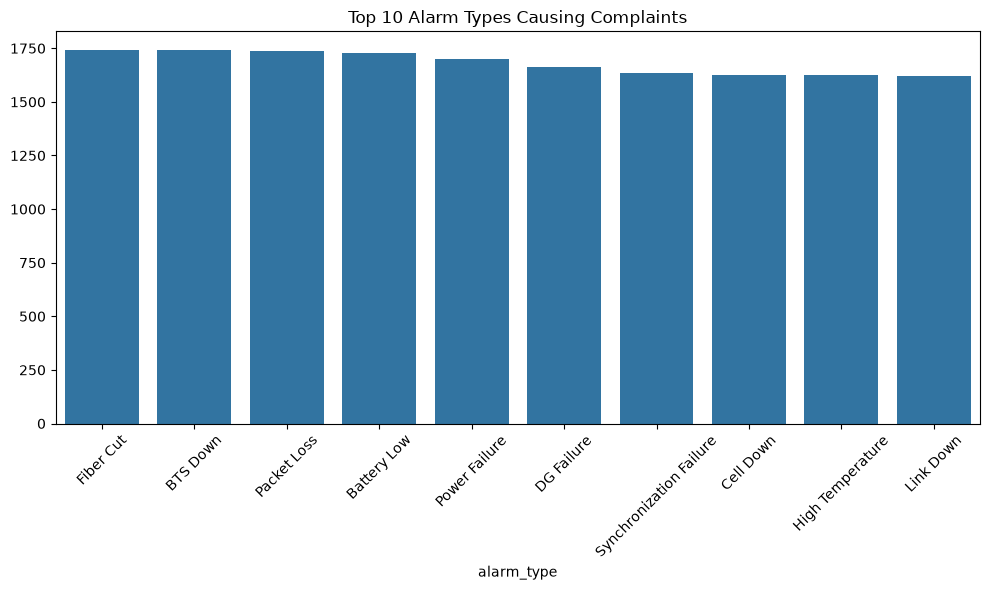

In [6]:

joined = pd.merge(complaints, alarms, left_on='related_alarm_id', right_on='alarm_id', how='inner', suffixes=('_comp', '_alarm'))

print(f"Matched {len(joined)} complaints to specific alarms via related_alarm_id.")


complaints_by_alarm_type = joined['alarm_type'].value_counts()
print("\nComplaints by Alarm Type:")
print(complaints_by_alarm_type.head())

plt.figure(figsize=(10,6))
sns.barplot(x=complaints_by_alarm_type.index[:10], y=complaints_by_alarm_type.values[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Alarm Types Causing Complaints')
plt.tight_layout()
plt.show()
